<a href="https://colab.research.google.com/github/swetha12g/DNN-SHA_Family/blob/main/Presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install tensorflow
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [11]:
import hashlib
import random
import string
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### Emulating a Hash Function with a Neural Network

This section demonstrates a basic approach to training a neural network to mimic the input-output relationship of a hash function (SHA-256 in this case). We'll generate random inputs, compute their actual SHA-256 hashes, encode this data for an NN, and then build and train a simple model.

In [14]:
# --- 1. Data Generation and Hashing ---

def generate_random_string(length):
    """Generates a random string of specified length."""
    letters = string.ascii_lowercase + string.digits
    return ''.join(random.choice(letters) for i in range(length))

def sha256_hash(input_string):
    """Computes the SHA-256 hash of a string and returns it as a binary string."""
    hash_object = hashlib.sha256(input_string.encode('utf-8'))
    hex_digest = hash_object.hexdigest()
    # Convert hex digest to binary string (256 bits)
    return bin(int(hex_digest, 16))[2:].zfill(256)

# Generate a dataset of (input_string, sha256_binary_hash) pairs
num_samples = 1000
string_length = 16 # Fixed length for simplicity in this example
dataset = []
for _ in range(num_samples):
    random_str = generate_random_string(string_length)
    hashed_binary = sha256_hash(random_str)
    dataset.append({'input': random_str, 'hash_binary': hashed_binary})

df_hashes = pd.DataFrame(dataset)
display(df_hashes.head())
print(f"Generated {len(df_hashes)} samples of random strings and their SHA-256 binary hashes.")
print(f"Example input string length: {len(df_hashes['input'].iloc[0])}")
print(f"Example hash binary length: {len(df_hashes['hash_binary'].iloc[0])}")

,input,hash_binary
0,yc0lihqxs1wm6qdx,1100011000101010011010110011010100011110001000...
1,4dnd867u7cgq1hnj,1010100011101001111110010100110001000010011010...
2,5daazs76a6ztdj2g,1010111010000010011100111011101100010000001000...
3,b9ipdr9ibyhybvct,1001100111111110010111001100010100110001100011...
4,3dhho658mhggm9bo,1100111010010011101010110100000011101100000100...


Generated 1000 samples of random strings and their SHA-256 binary hashes.
Example input string length: 16
Example hash binary length: 256


### Encoding Data for the Neural Network

Neural networks work with numerical data. We need to convert our input strings into numerical vectors and our binary hash strings into numerical binary vectors (0s and 1s).

In [15]:
# --- 2. Data Encoding ---

# Define the character set to create a consistent encoding
char_set = sorted(list(string.ascii_lowercase + string.digits))
char_to_int = {char: i for i, char in enumerate(char_set)}
int_to_char = {i: char for i, char in enumerate(char_set)}

# Function to one-hot encode a string
def encode_string(s, char_to_int, string_length):
    encoded = np.zeros((string_length, len(char_to_int)))
    for i, char in enumerate(s):
        if char in char_to_int:
            encoded[i, char_to_int[char]] = 1
    return encoded.flatten()

# Function to convert binary string to a numerical array
def encode_binary_hash(binary_str):
    return np.array([int(bit) for bit in binary_str])

# Encode all inputs (X) and outputs (y)
X_encoded = np.array([encode_string(row['input'], char_to_int, string_length) for _, row in df_hashes.iterrows()])
y_encoded = np.array([encode_binary_hash(row['hash_binary']) for _, row in df_hashes.iterrows()])

print(f"Shape of encoded inputs (X_encoded): {X_encoded.shape}")
print(f"Shape of encoded outputs (y_encoded): {y_encoded.shape}")
print(f"Example of encoded input (first 10 values): {X_encoded[0][:10]}")
print(f"Example of encoded output (first 10 values): {y_encoded[0][:10]}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"Train set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Shape of encoded inputs (X_encoded): (1000, 576)
Shape of encoded outputs (y_encoded): (1000, 256)
Example of encoded input (first 10 values): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Example of encoded output (first 10 values): [1 1 0 0 0 1 1 0 0 0]
Train set size: 800 samples
Test set size: 200 samples


### Building and Training the Neural Network Model

Now, we'll define a `Sequential` model to learn the mapping from encoded input strings to encoded SHA-256 binary hashes. The output layer will use a sigmoid activation for each bit, as we are essentially performing 256 independent binary classifications.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,544 (1.88 MB)

 Trainable params: 492,544 (1.88 MB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0000e+00 - loss: 0.6940 - val_accuracy: 0.0000e+00 - val_loss: 0.6939
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0014 - loss: 0.6863 - val_accuracy: 0.0000e+00 - val_loss: 0.6954
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0069 - loss: 0.6773 - val_accuracy: 0.0000e+00 - val_loss: 0.6965
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0042 - loss: 0.6632 - val_accuracy: 0.0000e+00 - val_loss: 0.6989
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0097 - loss: 0.6441 - val_accuracy: 0.0000e+00 - val_loss: 0.7050
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0069 - loss: 0.6217 - val_accuracy: 0.0000e+00 - val_loss: 0.7155
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0125 - loss: 0.5979 - val_accuracy: 0.0000e+00 - val_loss: 0.7241
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc

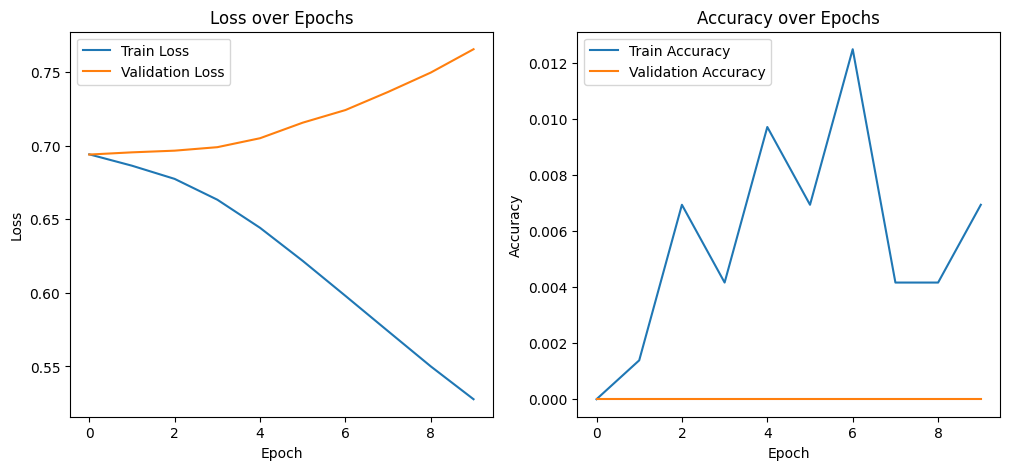

In [16]:
# --- 3. Build and Train the Neural Network Model ---

input_dim = X_train.shape[1]
hash_output_dim = y_train.shape[1] # Should be 256 for SHA-256

model_hash_emulator = Sequential([
    tf.keras.layers.Input(shape=(input_dim,)), # Recommended way to specify input_shape
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(hash_output_dim, activation='sigmoid') # Output layer, one sigmoid neuron per hash bit
])

# Compile the model
# Using binary_crossentropy for each bit, as it's a multi-label binary classification problem
model_hash_emulator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_hash_emulator.summary()

print("\nTraining the model...")
history = model_hash_emulator.fit(
    X_train, y_train,
    epochs=10, # You might need more epochs for better performance
    batch_size=32,
    validation_split=0.1, # Use a portion of training data for validation
    verbose=1
)

# --- 4. Evaluate the Model (Optional) ---
print("\nEvaluating the model on test data...")
loss, accuracy = model_hash_emulator.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy (bit-wise): {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Extending to SHA-1 and SHA-3 (SHA-3_256) Emulation

Below, we extend the deep neural network emulation to SHA-1 and SHA-3 (using SHA-3_256 for this example). The architecture will remain a Deep Multi-Layer Perceptron (DMLP) with similar hidden layer sizes, demonstrating the 'deep' aspect. However, it's critical to reiterate that these emulators are unlikely to achieve the cryptographic security properties (e.g., collision resistance, preimage resistance) of the actual SHA functions. The goal here is to demonstrate a deep learning approach to map inputs to hash outputs, which is a starting point for more advanced 'deep neural cryptography' concepts often discussed in research papers.

In [17]:
# --- SHA-1 Emulation ---

print("\n--- Starting SHA-1 Emulation ---")

# 1. Data Generation and Hashing for SHA-1
def sha1_hash(input_string):
    """Computes the SHA-1 hash of a string and returns it as a binary string."""
    hash_object = hashlib.sha1(input_string.encode('utf-8'))
    hex_digest = hash_object.hexdigest()
    return bin(int(hex_digest, 16))[2:].zfill(160) # SHA-1 produces 160-bit hash

num_samples_sha1 = 1000
dataset_sha1 = []
for _ in range(num_samples_sha1):
    random_str = generate_random_string(string_length) # Reusing string_length from SHA-256
    hashed_binary = sha1_hash(random_str)
    dataset_sha1.append({'input': random_str, 'hash_binary': hashed_binary})

df_hashes_sha1 = pd.DataFrame(dataset_sha1)
display(df_hashes_sha1.head())
print(f"Generated {len(df_hashes_sha1)} samples for SHA-1.")
print(f"Example SHA-1 binary hash length: {len(df_hashes_sha1['hash_binary'].iloc[0])}")



--- Starting SHA-1 Emulation ---


,input,hash_binary
0,4uoe7hl02m5ud6g6,0110011010101000000111010110010110111010111100...
1,boy20dbkn73ij2ee,0111000010000110001000000100010000111010101110...
2,hy2zxrd0vk6yeyfg,1011000001100000001101100010100110011000101000...
3,t20lzy4cm9546wcv,1111000011010000001011000001011010110100011100...
4,znmpc3xqyjbelmps,1110111100010111101000001001000110111010011110...


Generated 1000 samples for SHA-1.
Example SHA-1 binary hash length: 160


In [18]:
# 2. Data Encoding for SHA-1
X_encoded_sha1 = np.array([encode_string(row['input'], char_to_int, string_length) for _, row in df_hashes_sha1.iterrows()])
y_encoded_sha1 = np.array([encode_binary_hash(row['hash_binary']) for _, row in df_hashes_sha1.iterrows()])

X_train_sha1, X_test_sha1, y_train_sha1, y_test_sha1 = train_test_split(X_encoded_sha1, y_encoded_sha1, test_size=0.2, random_state=42)

print(f"Shape of encoded SHA-1 inputs (X_encoded_sha1): {X_encoded_sha1.shape}")
print(f"Shape of encoded SHA-1 outputs (y_encoded_sha1): {y_encoded_sha1.shape}")


Shape of encoded SHA-1 inputs (X_encoded_sha1): (1000, 576)
Shape of encoded SHA-1 outputs (y_encoded_sha1): (1000, 160)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 160)            │        41,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,872 (1.78 MB)

 Trainable params: 467,872 (1.78 MB)

 Non-trainable params: 0 (0.00 B)


Training the SHA-1 model...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.0000e+00 - loss: 0.6941 - val_accuracy: 0.0000e+00 - val_loss: 0.6939
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0000e+00 - loss: 0.6833 - val_accuracy: 0.0375 - val_loss: 0.6959
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0097 - loss: 0.6711 - val_accuracy: 0.0000e+00 - val_loss: 0.6980
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0069 - loss: 0.6516 - val_accuracy: 0.0500 - val_loss: 0.7030
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0069 - loss: 0.6263 - val_accuracy: 0.0125 - val_loss: 0.7127
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0097 - loss: 0.5970 - val_accuracy: 0.0125 - val_loss: 0.7225
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0069 - loss: 0.5655 - val_accuracy: 0.0125 - val_loss: 0.7404
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.005

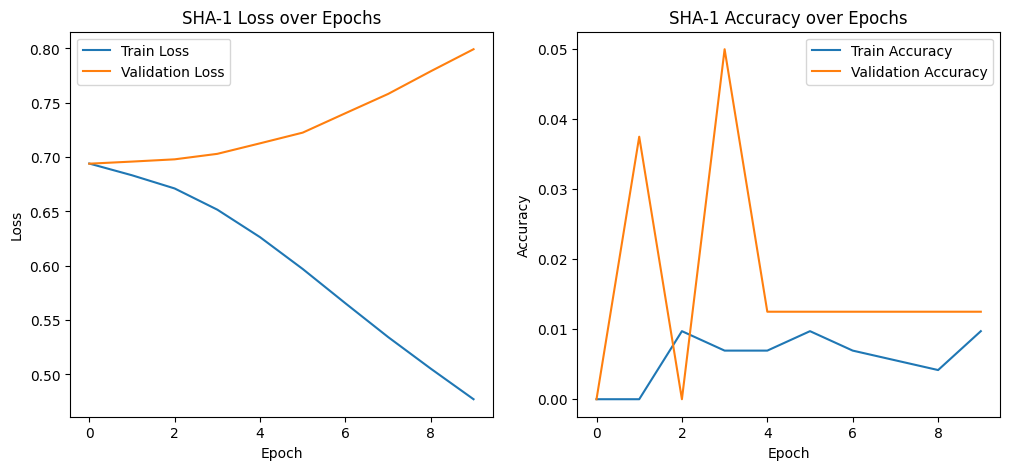

In [19]:
# 3. Build and Train the Neural Network Model for SHA-1

input_dim_sha1 = X_train_sha1.shape[1]
hash_output_dim_sha1 = y_train_sha1.shape[1] # Should be 160 for SHA-1

model_sha1_emulator = Sequential([
    tf.keras.layers.Input(shape=(input_dim_sha1,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(hash_output_dim_sha1, activation='sigmoid')
])

model_sha1_emulator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_sha1_emulator.summary()

print("\nTraining the SHA-1 model...")
history_sha1 = model_sha1_emulator.fit(
    X_train_sha1, y_train_sha1,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nEvaluating the SHA-1 model on test data...")
loss_sha1, accuracy_sha1 = model_sha1_emulator.evaluate(X_test_sha1, y_test_sha1, verbose=0)
print(f"SHA-1 Test Loss: {loss_sha1:.4f}")
print(f"SHA-1 Test Accuracy (bit-wise): {accuracy_sha1:.4f}")

# Plot training history for SHA-1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sha1.history['loss'], label='Train Loss')
plt.plot(history_sha1.history['val_loss'], label='Validation Loss')
plt.title('SHA-1 Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sha1.history['accuracy'], label='Train Accuracy')
plt.plot(history_sha1.history['val_accuracy'], label='Validation Accuracy')
plt.title('SHA-1 Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### SHA-3 (SHA-3_256) Emulation

Here we perform the same deep neural network emulation for SHA-3. We'll use SHA-3_256 for direct comparison with SHA-256.

In [20]:
# --- SHA-3 (SHA-3_256) Emulation ---

print("\n--- Starting SHA-3 (SHA-3_256) Emulation ---")

# 1. Data Generation and Hashing for SHA-3_256
def sha3_256_hash(input_string):
    """Computes the SHA-3_256 hash of a string and returns it as a binary string."""
    hash_object = hashlib.sha3_256(input_string.encode('utf-8'))
    hex_digest = hash_object.hexdigest()
    return bin(int(hex_digest, 16))[2:].zfill(256) # SHA-3_256 produces 256-bit hash

num_samples_sha3 = 1000
dataset_sha3 = []
for _ in range(num_samples_sha3):
    random_str = generate_random_string(string_length)
    hashed_binary = sha3_256_hash(random_str)
    dataset_sha3.append({'input': random_str, 'hash_binary': hashed_binary})

df_hashes_sha3 = pd.DataFrame(dataset_sha3)
display(df_hashes_sha3.head())
print(f"Generated {len(df_hashes_sha3)} samples for SHA-3_256.")
print(f"Example SHA-3_256 binary hash length: {len(df_hashes_sha3['hash_binary'].iloc[0])}")



--- Starting SHA-3 (SHA-3_256) Emulation ---


,input,hash_binary
0,yi466j7hv8ifpdep,1110011100001110010011100111010010101010111100...
1,d1ba1gg4pucs62sv,1111100000111011011111010001100101111001100100...
2,yxw8oqddp6yuznm6,0101100000111000110000110010101011000100110110...
3,dp4epr2bw3getkkd,0100100111110010111100001100110001000011000000...
4,1jktg0atyn3f7w0f,0001101110011110001001011111001011001111100111...


Generated 1000 samples for SHA-3_256.
Example SHA-3_256 binary hash length: 256


In [21]:
# 2. Data Encoding for SHA-3_256
X_encoded_sha3 = np.array([encode_string(row['input'], char_to_int, string_length) for _, row in df_hashes_sha3.iterrows()])
y_encoded_sha3 = np.array([encode_binary_hash(row['hash_binary']) for _, row in df_hashes_sha3.iterrows()])

X_train_sha3, X_test_sha3, y_train_sha3, y_test_sha3 = train_test_split(X_encoded_sha3, y_encoded_sha3, test_size=0.2, random_state=42)

print(f"Shape of encoded SHA-3 inputs (X_encoded_sha3): {X_encoded_sha3.shape}")
print(f"Shape of encoded SHA-3 outputs (y_encoded_sha3): {y_encoded_sha3.shape}")


Shape of encoded SHA-3 inputs (X_encoded_sha3): (1000, 576)
Shape of encoded SHA-3 outputs (y_encoded_sha3): (1000, 256)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,544 (1.88 MB)

 Trainable params: 492,544 (1.88 MB)

 Non-trainable params: 0 (0.00 B)


Training the SHA-3 model...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0222 - loss: 0.6940 - val_accuracy: 0.0375 - val_loss: 0.6935
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0208 - loss: 0.6859 - val_accuracy: 0.0250 - val_loss: 0.6953
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0153 - loss: 0.6769 - val_accuracy: 0.0125 - val_loss: 0.6962
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0181 - loss: 0.6626 - val_accuracy: 0.0000e+00 - val_loss: 0.6992
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0222 - loss: 0.6437 - val_accuracy: 0.0000e+00 - val_loss: 0.7047
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0111 - loss: 0.6212 - val_accuracy: 0.0000e+00 - val_loss: 0.7147
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0194 - loss: 0.5972 - val_accuracy: 0.0000e+00 - val_loss: 0.7250
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0

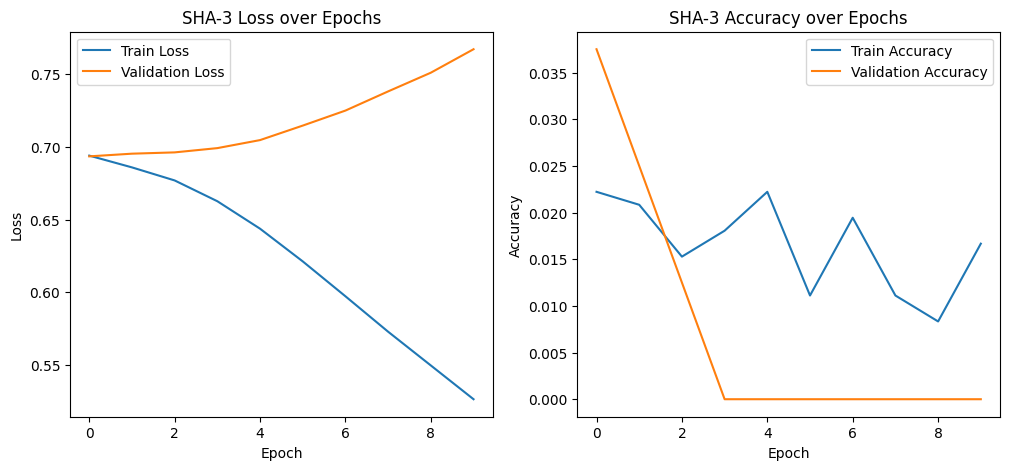

In [22]:
# 3. Build and Train the Neural Network Model for SHA-3_256

input_dim_sha3 = X_train_sha3.shape[1]
hash_output_dim_sha3 = y_train_sha3.shape[1] # Should be 256 for SHA-3_256

model_sha3_emulator = Sequential([
    tf.keras.layers.Input(shape=(input_dim_sha3,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(hash_output_dim_sha3, activation='sigmoid')
])

model_sha3_emulator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_sha3_emulator.summary()

print("\nTraining the SHA-3 model...")
history_sha3 = model_sha3_emulator.fit(
    X_train_sha3, y_train_sha3,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nEvaluating the SHA-3 model on test data...")
loss_sha3, accuracy_sha3 = model_sha3_emulator.evaluate(X_test_sha3, y_test_sha3, verbose=0)
print(f"SHA-3 Test Loss: {loss_sha3:.4f}")
print(f"SHA-3 Test Accuracy (bit-wise): {accuracy_sha3:.4f}")

# Plot training history for SHA-3
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sha3.history['loss'], label='Train Loss')
plt.plot(history_sha3.history['val_loss'], label='Validation Loss')
plt.title('SHA-3 Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sha3.history['accuracy'], label='Train Accuracy')
plt.plot(history_sha3.history['val_accuracy'], label='Validation Accuracy')
plt.title('SHA-3 Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
